# Линейная регрессия: переобучение и регуляризация

Исследуем, как степень полинома влияет на ошибку, и сравним Linear Regression, Ridge и Lasso на сложном признаковом пространстве.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid")

## Данные

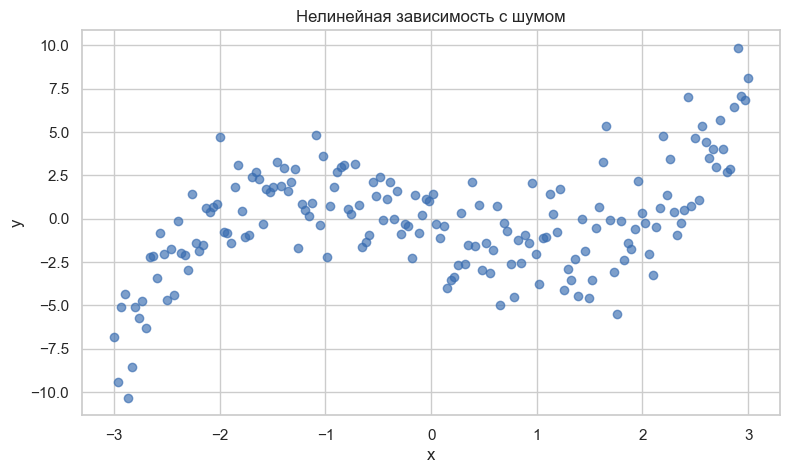

In [2]:
rng = np.random.default_rng(42)
x = np.linspace(-3, 3, 180)
y = 0.5 * x ** 3 - 2 * x + rng.normal(0, 2.2, len(x))
features = x.reshape(-1, 1)
train_features, test_features, train_target, test_target = train_test_split(
    features, y, test_size=0.3, random_state=42
)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.65, color="#386cb0")
plt.title("Нелинейная зависимость с шумом")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Сложность модели

,degree,train_mse,test_mse
0,1,8.543336,8.131240
1,2,8.543200,8.139569
2,3,3.468397,3.878207
3,5,3.413411,3.883262
4,8,3.410406,3.907796
5,12,3.313924,4.251392
6,15,3.247290,4.457028


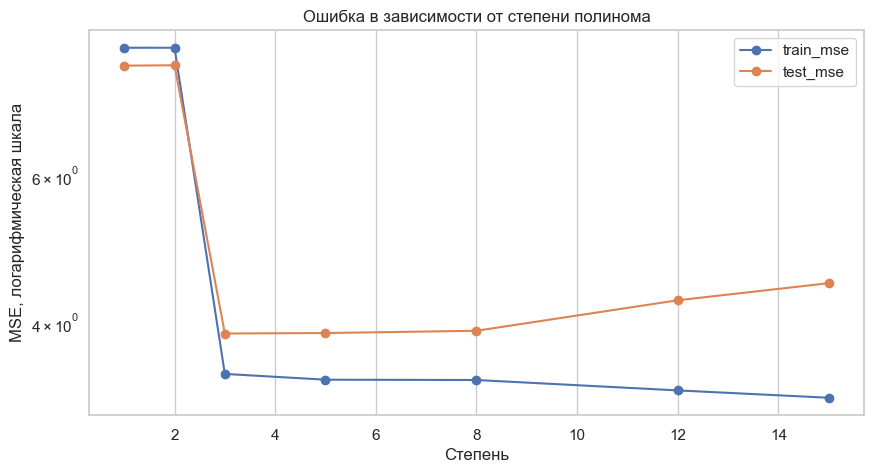

In [3]:
degree_rows = []
for degree in [1, 2, 3, 5, 8, 12, 15]:
    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", LinearRegression()),
    ])
    model.fit(train_features, train_target)
    degree_rows.append({
        "degree": degree,
        "train_mse": mean_squared_error(train_target, model.predict(train_features)),
        "test_mse": mean_squared_error(test_target, model.predict(test_features)),
    })

degree_results = pd.DataFrame(degree_rows)
display(degree_results)

degree_results.set_index("degree")[["train_mse", "test_mse"]].plot(marker="o", figsize=(10, 5))
plt.yscale("log")
plt.title("Ошибка в зависимости от степени полинома")
plt.xlabel("Степень")
plt.ylabel("MSE, логарифмическая шкала")
plt.show()

## Регуляризация

,train_mse,test_mse
model,,
Linear Regression,3.247290,4.457028
Ridge,3.813081,4.161503
Lasso,3.489098,3.902027


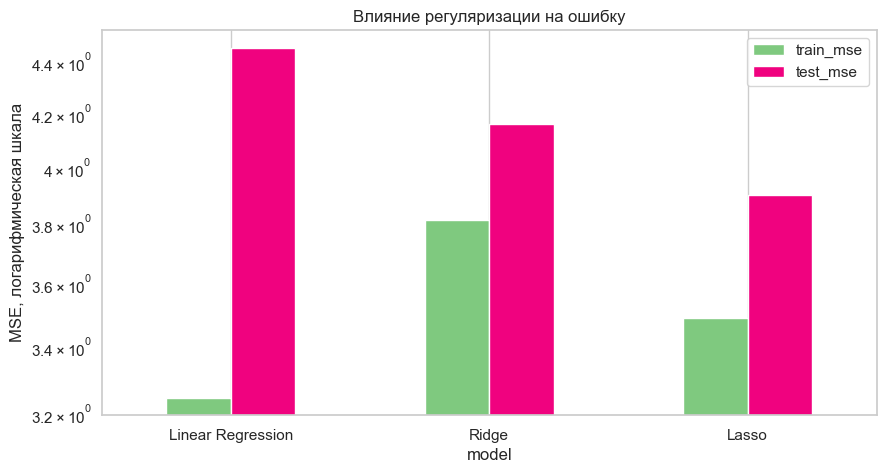

In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.03, max_iter=100000),
}
regularization_rows = []
fitted_models = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ("polynomial", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    pipeline.fit(train_features, train_target)
    fitted_models[name] = pipeline
    regularization_rows.append({
        "model": name,
        "train_mse": mean_squared_error(train_target, pipeline.predict(train_features)),
        "test_mse": mean_squared_error(test_target, pipeline.predict(test_features)),
    })

regularization_results = pd.DataFrame(regularization_rows).set_index("model")
display(regularization_results)
regularization_results.plot.bar(figsize=(10, 5), color=["#7fc97f", "#f0027f"])
plt.yscale("log")
plt.title("Влияние регуляризации на ошибку")
plt.ylabel("MSE, логарифмическая шкала")
plt.xticks(rotation=0)
plt.show()

## Кривые моделей

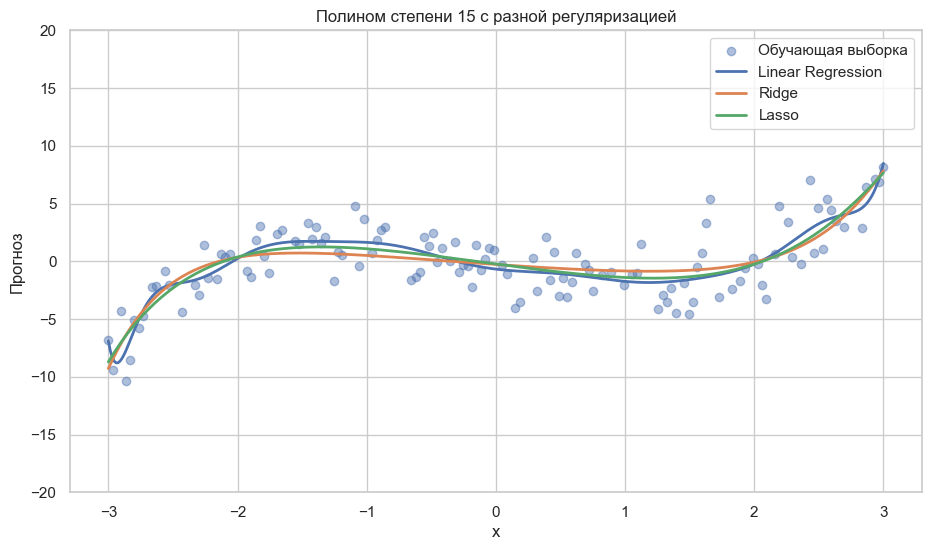

In [5]:
grid = np.linspace(-3, 3, 400).reshape(-1, 1)
plt.figure(figsize=(11, 6))
plt.scatter(train_features[:, 0], train_target, alpha=0.45, label="Обучающая выборка")
for name, model in fitted_models.items():
    plt.plot(grid[:, 0], model.predict(grid), linewidth=2, label=name)
plt.ylim(-20, 20)
plt.title("Полином степени 15 с разной регуляризацией")
plt.xlabel("x")
plt.ylabel("Прогноз")
plt.legend()
plt.show()

## Вывод

Рост сложности снижает ошибку на обучении, но после оптимальной степени test-ошибка увеличивается. Ridge и Lasso ограничивают коэффициенты и уменьшают переобучение.